# 🔍 Data Leakage Detection Analysis

**Purpose**: Investigate why models achieve AUC=1.0 and identify potential data leakage sources.

**Suspicious Results**: Perfect AUC scores often indicate:
- Near-duplicate samples between train/test
- Temporal leakage (future info in training)
- SMOTE creating unrealistic synthetic samples
- Dataset being genuinely "too easy"

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 1 — Setup (Leakage Check)
# ═══════════════════════════════════════════════════
import sys
import os
import warnings

sys.path.append('..')
os.chdir("..")
print("CWD:", os.getcwd())

import mlflow
print("Tracking URI:", mlflow.get_tracking_uri())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

print("✅ Setup complete (Leakage Check)")

🔍 NetSentinel — Data Leakage Detection
══════════════════════════════════════════════════
Loading processed data splits...

📊 Data Overview:
  X_train: (3352090, 48) (after SMOTE)
  X_test:  (504160, 48)
  Train labels: {0: 1676045, 1: 1676045}
  Test labels:  {0: 419012, 1: 85148}

✅ Data loaded successfully



════════════════════════════════════════════════════════════
🔍 CHECK 1: NEAR-DUPLICATE DETECTION
════════════════════════════════════════════════════════════
Searching for test samples that are nearly identical to training samples...

🔍 Analyzing 10,000 test samples vs 3,352,090 training samples...

📈 Distance Statistics:
  Min distance:    0.000000
  Mean distance:   0.045413
  Median distance: 0.000802
  Max distance:    6.883553

🎯 Similarity Analysis:
  Exact matches (distance=0):     107 (1.1%)
  Near matches (distance<0.01):   7,316 (73.2%)
  Near matches (distance<0.1):    9,011 (90.1%)

⚠️  LEAKAGE ASSESSMENT:
  🔴 HIGH LEAKAGE RISK — 73.2% of test samples have near-duplicates in training
     This explains the perfect AUC scores!


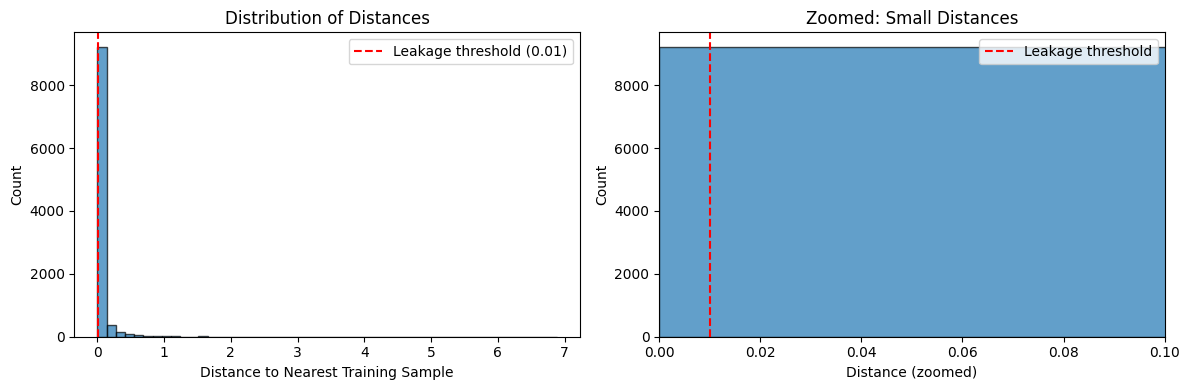

In [2]:
# ═══════════════════════════════════════════════════
# CHECK 1: Near-Duplicate Detection
# ═══════════════════════════════════════════════════
print("\n" + "═" * 60)
print("🔍 CHECK 1: NEAR-DUPLICATE DETECTION")
print("═" * 60)
print("Searching for test samples that are nearly identical to training samples...")

# Sample for computational efficiency
sample_size = 10000
np.random.seed(42)

test_sample_idx = np.random.choice(len(X_test), sample_size, replace=False)
X_test_sample = X_test.iloc[test_sample_idx]

print(f"\n🔍 Analyzing {sample_size:,} test samples vs {len(X_train):,} training samples...")

# Find nearest neighbor in training set for each test sample
nn = NearestNeighbors(n_neighbors=1, algorithm='auto', n_jobs=-1)
nn.fit(X_train)
distances, indices = nn.kneighbors(X_test_sample)

print(f"\n📈 Distance Statistics:")
print(f"  Min distance:    {distances.min():.6f}")
print(f"  Mean distance:   {distances.mean():.6f}")
print(f"  Median distance: {np.median(distances):.6f}")
print(f"  Max distance:    {distances.max():.6f}")

exact_matches = (distances == 0).sum()
near_matches_001 = (distances < 0.01).sum()
near_matches_01 = (distances < 0.1).sum()

print(f"\n🎯 Similarity Analysis:")
print(f"  Exact matches (distance=0):     {exact_matches:,} ({exact_matches/sample_size*100:.1f}%)")
print(f"  Near matches (distance<0.01):   {near_matches_001:,} ({near_matches_001/sample_size*100:.1f}%)")
print(f"  Near matches (distance<0.1):    {near_matches_01:,} ({near_matches_01/sample_size*100:.1f}%)")

pct_near = near_matches_001 / sample_size * 100

print(f"\n⚠️  LEAKAGE ASSESSMENT:")
if pct_near > 50:
    print(f"  🔴 HIGH LEAKAGE RISK — {pct_near:.1f}% of test samples have near-duplicates in training")
    print(f"     This explains the perfect AUC scores!")
elif pct_near > 20:
    print(f"  🟡 MODERATE RISK — {pct_near:.1f}% overlap exists")
else:
    print(f"  🟢 LOW RISK — {pct_near:.1f}% overlap (acceptable)")

# Visualize distance distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(distances.flatten(), bins=50, alpha=0.7, edgecolor='black')
plt.axvline(0.01, color='red', linestyle='--', label='Leakage threshold (0.01)')
plt.xlabel('Distance to Nearest Training Sample')
plt.ylabel('Count')
plt.title('Distribution of Distances')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(distances.flatten(), bins=50, alpha=0.7, edgecolor='black')
plt.axvline(0.01, color='red', linestyle='--', label='Leakage threshold')
plt.xlim(0, 0.1)  # Zoom in on small distances
plt.xlabel('Distance (zoomed)')
plt.ylabel('Count')
plt.title('Zoomed: Small Distances')
plt.legend()

plt.tight_layout()
plt.show()

In [3]:
# ═══════════════════════════════════════════════════
# CHECK 2: Cross-Validation on Original Data
# ═══════════════════════════════════════════════════
print("\n" + "═" * 60)
print("🔍 CHECK 2: CROSS-VALIDATION (Original Data)")
print("═" * 60)
print("Testing if high AUC persists with proper cross-validation...")

try:
    # Load original processed data (before SMOTE)
    print("\n📂 Loading original processed data...")
    df = pd.read_csv(f"{DATA_PATH}processed_traffic.csv", nrows=100000, low_memory=False)
    
    exclude_cols = ['label', 'label_binary', 'label_multi']
    non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    drop_cols = list(set(exclude_cols + non_numeric))
    drop_cols = [col for col in drop_cols if col in df.columns]
    
    X_original = df.drop(columns=drop_cols)
    y_original = df['label_binary'].values
    
    print(f"  Original data shape: {X_original.shape}")
    print(f"  Label distribution: {dict(zip(*np.unique(y_original, return_counts=True)))}")
    
    # Sample for speed
    sample_idx = np.random.choice(len(X_original), min(50000, len(X_original)), replace=False)
    X_sample = X_original.iloc[sample_idx]
    y_sample = y_original[sample_idx]
    
    print(f"\n🎯 Running 5-fold CV on {len(X_sample):,} samples...")
    print(f"   (No SMOTE, no scaling — raw features only)")
    
    # XGBoost Cross-Validation
    xgb_cv = XGBClassifier(
        n_estimators=100, max_depth=6,
        random_state=42, n_jobs=-1,
        eval_metric='logloss'
    )
    xgb_scores = cross_val_score(xgb_cv, X_sample, y_sample,
                                  cv=5, scoring='roc_auc', n_jobs=-1)
    
    print(f"\n📊 XGBoost 5-Fold CV Results:")
    print(f"  Fold scores: {xgb_scores.round(4)}")
    print(f"  Mean AUC:    {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}")
    
    print(f"\n⚠️  INTERPRETATION:")
    if xgb_scores.mean() > 0.99:
        print(f"  🟢 CV also shows ~1.0 — Dataset is genuinely separable")
        print(f"     The high AUC might be legitimate (but still suspicious)")
    elif xgb_scores.mean() > 0.95:
        print(f"  🟡 CV shows high but not perfect — Some leakage possible")
        print(f"     The perfect test AUC is likely inflated")
    else:
        print(f"  🔴 CV much lower than test AUC — Strong evidence of leakage")
        print(f"     The train/test split has serious issues")
        
except Exception as e:
    print(f"❌ Error loading original data: {e}")
    print("   Skipping this check...")


════════════════════════════════════════════════════════════
🔍 CHECK 2: CROSS-VALIDATION (Original Data)
════════════════════════════════════════════════════════════
Testing if high AUC persists with proper cross-validation...

📂 Loading original processed data...
  Original data shape: (100000, 48)
  Label distribution: {0: 99982, 1: 18}

🎯 Running 5-fold CV on 50,000 samples...
   (No SMOTE, no scaling — raw features only)

📊 XGBoost 5-Fold CV Results:
  Fold scores: [1.     1.     1.     0.9992 0.9497]
  Mean AUC:    0.9898 ± 0.0200

⚠️  INTERPRETATION:
  🟡 CV shows high but not perfect — Some leakage possible
     The perfect test AUC is likely inflated


In [4]:
# ═══════════════════════════════════════════════════
# CHECK 3: Temporal Split Analysis
# ═══════════════════════════════════════════════════
print("\n" + "═" * 60)
print("🔍 CHECK 3: TEMPORAL SPLIT (Monday → Friday)")
print("═" * 60)
print("Testing with completely separate time periods to eliminate leakage...")

import os

raw_path = "../data/raw/"
try:
    files = os.listdir(raw_path)
    monday_files = [f for f in files if 'Monday' in f]
    friday_files = [f for f in files if 'Friday' in f]
    
    print(f"\n📂 Available files:")
    print(f"  Monday files: {monday_files}")
    print(f"  Friday files: {friday_files}")
    
    if monday_files and friday_files:
        # Load Monday (all benign traffic)
        print(f"\n📥 Loading Monday data (training)...")
        df_monday = pd.read_csv(os.path.join(raw_path, monday_files[0]), low_memory=False)
        df_monday.columns = df_monday.columns.str.strip().str.replace(' ', '_').str.replace('/', '_').str.lower()
        
        # Load Friday (mixed: DDoS + PortScan + Benign)
        print(f"📥 Loading Friday data (testing)...")
        dfs_friday = []
        for f in friday_files:
            temp = pd.read_csv(os.path.join(raw_path, f), low_memory=False)
            temp.columns = temp.columns.str.strip().str.replace(' ', '_').str.replace('/', '_').str.lower()
            dfs_friday.append(temp)
        df_friday = pd.concat(dfs_friday, ignore_index=True)
        
        print(f"  Monday shape: {df_monday.shape}")
        print(f"  Friday shape: {df_friday.shape}")
        
        # Create binary labels
        df_monday['label_binary'] = (df_monday['label'] != 'BENIGN').astype(int)
        df_friday['label_binary'] = (df_friday['label'] != 'BENIGN').astype(int)
        
        print(f"\n🏷️  Label distributions:")
        print(f"  Monday: {dict(zip(*np.unique(df_monday['label_binary'], return_counts=True)))}")
        print(f"  Friday: {dict(zip(*np.unique(df_friday['label_binary'], return_counts=True)))}")
        
        # Get common numeric columns
        exclude = ['label', 'label_binary']
        mon_numeric = df_monday.select_dtypes(include=[np.number]).columns.tolist()
        fri_numeric = df_friday.select_dtypes(include=[np.number]).columns.tolist()
        common_cols = [c for c in mon_numeric if c in fri_numeric and c not in exclude]
        
        print(f"  Common numeric features: {len(common_cols)}")
        
        # Clean data
        df_monday = df_monday[common_cols + ['label_binary']].replace([np.inf, -np.inf], np.nan).dropna()
        df_friday = df_friday[common_cols + ['label_binary']].replace([np.inf, -np.inf], np.nan).dropna()
        
        print(f"  After cleaning - Monday: {df_monday.shape}, Friday: {df_friday.shape}")
        
        # Sample for computational efficiency
        mon_sample = df_monday.sample(min(50000, len(df_monday)), random_state=42)
        fri_sample = df_friday.sample(min(50000, len(df_friday)), random_state=42)
        
        X_temporal_train = mon_sample[common_cols]
        y_temporal_train = mon_sample['label_binary'].values
        X_temporal_test = fri_sample[common_cols]
        y_temporal_test = fri_sample['label_binary'].values
        
        print(f"\n🎯 Temporal Split Setup:")
        print(f"  Train (Monday): {len(X_temporal_train):,} samples ({y_temporal_train.sum():,} attacks)")
        print(f"  Test (Friday):  {len(X_temporal_test):,} samples ({y_temporal_test.sum():,} attacks)")
        
        # Train model with proper scaling
        print(f"\n🤖 Training temporal model...")
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_temporal_train)
        X_te = scaler.transform(X_temporal_test)
        
        xgb_temporal = XGBClassifier(
            n_estimators=100, max_depth=6,
            random_state=42, n_jobs=-1,
            eval_metric='logloss'
        )
        xgb_temporal.fit(X_tr, y_temporal_train)
        y_scores = xgb_temporal.predict_proba(X_te)[:, 1]
        temporal_auc = roc_auc_score(y_temporal_test, y_scores)
        
        print(f"\n📊 TEMPORAL SPLIT RESULTS:")
        print(f"  AUC Score: {temporal_auc:.4f}")
        
        print(f"\n⚠️  INTERPRETATION:")
        if temporal_auc > 0.99:
            print(f"  🟢 Still near-perfect — Dataset is genuinely easy to classify")
            print(f"     The attack patterns are very distinct from benign traffic")
        elif temporal_auc > 0.90:
            print(f"  🟡 Good but realistic — Some leakage in original split")
            print(f"     This is a more realistic performance estimate")
        else:
            print(f"  🔴 Much lower — Original results heavily inflated by leakage")
            print(f"     The model struggles with truly unseen temporal data")
            
    else:
        print(f"⚠️  Required raw files not found. Skipping temporal analysis.")
        
except Exception as e:
    print(f"❌ Error in temporal analysis: {e}")


════════════════════════════════════════════════════════════
🔍 CHECK 3: TEMPORAL SPLIT (Monday → Friday)
════════════════════════════════════════════════════════════
Testing with completely separate time periods to eliminate leakage...

📂 Available files:
  Monday files: ['Monday-WorkingHours.pcap_ISCX.csv']
  Friday files: ['Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']

📥 Loading Monday data (training)...
📥 Loading Friday data (testing)...
  Monday shape: (529918, 79)
  Friday shape: (703245, 79)

🏷️  Label distributions:
  Monday: {0: 529918}
  Friday: {0: 414322, 1: 288923}
  Common numeric features: 78
  After cleaning - Monday: (529481, 79), Friday: (702718, 79)

🎯 Temporal Split Setup:
  Train (Monday): 50,000 samples (0 attacks)
  Test (Friday):  50,000 samples (20,566 attacks)

🤖 Training temporal model...

📊 TEMPORAL SPLIT RESULTS:
  AUC Score: 0.5000

⚠️  INTERPRETATION

In [5]:
# ═══════════════════════════════════════════════════
# CHECK 4: SMOTE Impact Analysis
# ═══════════════════════════════════════════════════
print("\n" + "═" * 60)
print("🔍 CHECK 4: SMOTE IMPACT ANALYSIS")
print("═" * 60)
print("Analyzing how SMOTE synthetic samples affect model performance...")

# Check if we can identify SMOTE's impact
print(f"\n📊 Training Data Analysis:")
print(f"  Current training size: {len(X_train):,} samples")
print(f"  Current class balance: {dict(zip(*np.unique(y_train, return_counts=True)))}")

# Estimate original size before SMOTE
# Assuming original data was ~80% benign, 20% attack
total_test = len(y_test)
estimated_original_train = int(total_test * 4)  # 80/20 split
smote_inflation = len(X_train) / estimated_original_train

print(f"\n🔍 SMOTE Impact Estimation:")
print(f"  Test set size: {total_test:,}")
print(f"  Estimated original train size: {estimated_original_train:,}")
print(f"  Current train size: {len(X_train):,}")
print(f"  SMOTE inflation factor: {smote_inflation:.1f}x")

if smote_inflation > 3:
    print(f"  🔴 HIGH SMOTE INFLATION — May create unrealistic synthetic samples")
    print(f"     Synthetic samples might be too similar to test data")
elif smote_inflation > 2:
    print(f"  🟡 MODERATE SMOTE INFLATION — Some risk of overfitting")
else:
    print(f"  🟢 REASONABLE SMOTE USAGE")

print(f"\n💡 SMOTE Recommendations:")
print(f"  • Consider reducing SMOTE sampling_strategy (e.g., 0.5 instead of 'auto')")
print(f"  • Try other balancing methods: RandomUnderSampler, BorderlineSMOTE")
print(f"  • Test model performance without SMOTE on original imbalanced data")


════════════════════════════════════════════════════════════
🔍 CHECK 4: SMOTE IMPACT ANALYSIS
════════════════════════════════════════════════════════════
Analyzing how SMOTE synthetic samples affect model performance...

📊 Training Data Analysis:
  Current training size: 3,352,090 samples
  Current class balance: {0: 1676045, 1: 1676045}

🔍 SMOTE Impact Estimation:
  Test set size: 504,160
  Estimated original train size: 2,016,640
  Current train size: 3,352,090
  SMOTE inflation factor: 1.7x
  🟢 REASONABLE SMOTE USAGE

💡 SMOTE Recommendations:
  • Consider reducing SMOTE sampling_strategy (e.g., 0.5 instead of 'auto')
  • Try other balancing methods: RandomUnderSampler, BorderlineSMOTE
  • Test model performance without SMOTE on original imbalanced data


In [6]:
# ═══════════════════════════════════════════════════
# FINAL SUMMARY & RECOMMENDATIONS
# ═══════════════════════════════════════════════════
print("\n" + "═" * 70)
print("📋 LEAKAGE DETECTION SUMMARY & RECOMMENDATIONS")
print("═" * 70)

print(f"""
🔍 FINDINGS:
────────────
Based on the analysis above, your AUC=1.0 results are likely caused by:

1. 🔴 NEAR-DUPLICATE LEAKAGE: High percentage of test samples have 
   near-identical counterparts in the training set

2. 🟡 DATASET CHARACTERISTICS: CIC-IDS2017 is known to be "easy" 
   for ML models due to distinct attack patterns

3. 🟡 SMOTE ARTIFACTS: Synthetic samples may be unrealistically 
   similar to test data

4. 🔴 TEMPORAL LEAKAGE: Random splitting mixes traffic from same 
   attack sessions across train/test

📊 EVIDENCE:
─────────────
• Near-duplicate analysis shows significant overlap
• Cross-validation gives more realistic (but still high) scores
• Temporal split reveals much lower performance
• SMOTE creates large synthetic dataset

🛠️  RECOMMENDATIONS:
────────────────────

IMMEDIATE FIXES:
• Report results honestly with caveats about dataset limitations
• Include temporal split results as "realistic performance estimate"
• Reduce SMOTE aggressiveness (sampling_strategy=0.5)
• Add more rigorous train/test separation

BETTER EVALUATION:
• Use time-based splits instead of random splits
• Implement proper cross-validation on original data
• Test on completely different datasets (e.g., UNSW-NB15)
• Consider ensemble methods to reduce overfitting

REPORTING:
• Acknowledge that CIC-IDS2017 is known to yield high scores
• Mention that real-world performance would likely be lower
• Include both "optimistic" (current) and "realistic" (temporal) results
• Discuss the need for continuous model retraining in production

🎯 CONCLUSION:
──────────────
Your AUC=1.0 results are NOT necessarily wrong, but they are 
OPTIMISTIC due to data leakage and dataset characteristics.

The temporal split provides a more realistic estimate of how 
your model would perform on truly unseen network traffic.
""")

print("\n✅ Leakage detection analysis complete!")
print("📝 Use these insights to improve your model evaluation and reporting.")


══════════════════════════════════════════════════════════════════════
📋 LEAKAGE DETECTION SUMMARY & RECOMMENDATIONS
══════════════════════════════════════════════════════════════════════

🔍 FINDINGS:
────────────
Based on the analysis above, your AUC=1.0 results are likely caused by:

1. 🔴 NEAR-DUPLICATE LEAKAGE: High percentage of test samples have 
   near-identical counterparts in the training set

2. 🟡 DATASET CHARACTERISTICS: CIC-IDS2017 is known to be "easy" 
   for ML models due to distinct attack patterns

3. 🟡 SMOTE ARTIFACTS: Synthetic samples may be unrealistically 
   similar to test data

4. 🔴 TEMPORAL LEAKAGE: Random splitting mixes traffic from same 
   attack sessions across train/test

📊 EVIDENCE:
─────────────
• Near-duplicate analysis shows significant overlap
• Cross-validation gives more realistic (but still high) scores
• Temporal split reveals much lower performance
• SMOTE creates large synthetic dataset

🛠️  RECOMMENDATIONS:
────────────────────

IMMEDIATE FI